<a href="https://colab.research.google.com/github/Maryvictor/fraud-detection-ml/blob/aula-01/fraud_detection_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Detecção de Fraudes em Transações Bancárias

## Sobre o Dataset

Este projeto utiliza o dataset **Fraud Detection Example**, disponível no Kaggle
(licença CC BY-SA 4.0), que contém transações bancárias simuladas com o objetivo
de identificar operações fraudulentas.

O arquivo `fraud_dataset_example.csv` (~7,78 MB) possui **11 colunas**, sendo elas:

| Coluna | Descrição |
|---|---|
| `step` | Unidade de tempo (1 unidade = 1 hora) |
| `type` | Tipo de transação: CASH-IN, CASH-OUT, DEBIT, PAYMENT ou TRANSFER |
| `amount` | Valor da transação na moeda local |
| `nameOrig` | Identificador do cliente que originou a transação |
| `oldbalanceOrg` | Saldo inicial do remetente (antes da transação) |
| `newbalanceOrig` | Saldo do remetente após a transação |
| `nameDest` | Identificador do destinatário |
| `oldbalanceDest` | Saldo inicial do destinatário (antes da transação) |
| `newbalanceDest` | Saldo do destinatário após a transação |
| `isFraud` | **Alvo principal** — indica se a transação é fraude (1) ou não (0) |
| `isFlaggedFraud` | Tentativa ilegal de transferir grandes quantias em uma única transação |

## Objetivo

Construir um modelo de **classificação binária** capaz de identificar se uma
transação bancária é fraudulenta ou não, com base nas características da operação.

> 💡 Fraudes neste dataset ocorrem quando agentes maliciosos assumem o controle
> de contas e tentam esvaziá-las via transferências e saques em sequência.

## Fonte

Dataset: [Fraud Detection Example — Kaggle](https://www.kaggle.com/datasets/gopalmahadevan/fraud-detection-example)

## Passo 1 — Importar o Pandas

In [82]:
import io
import pandas as pd
import gspread
from google.colab import auth
from google.auth import default

# Autentica no Google
auth.authenticate_user()

# Pega credenciais com os escopos certos para Drive e Sheets
creds, _ = default(scopes=[
    'https://www.googleapis.com/auth/spreadsheets',
    'https://www.googleapis.com/auth/drive'
])

gc = gspread.Client(auth=creds)

# Abre o arquivo pelo nome
sh = gc.open('fraud_dataset_example')



## Passo 2 — Carregar o dataset

In [83]:
# Pega a primeira aba e converte pra DataFrame
df = pd.DataFrame(sh.sheet1.get_all_records())

print(f'Shape: {df.shape}')
df

Shape: (101613, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
101608,10,PAYMENT,7477.02,C513257306,785.00,0.00,M524833426,0.00,0.00,0,0
101609,10,CASH_OUT,282252.35,C210473293,220339.29,0.00,C1172042998,95156.01,91286.97,0,0
101610,10,PAYMENT,17289.01,C807582280,0.00,0.00,M334249577,0.00,0.00,0,0
101611,10,TRANSFER,1347146.45,C1315779140,1605.00,0.00,C1631408038,541639.43,2186953.43,0,0


**Resultado:** uma tabela com 101.613 linhas e 11 colunas — os dados do PaySim.

## Passo 3 — Ver os nomes das colunas



Isso lista todos os nomes das colunas da tabela. Usamos aqui para copiar os nomes exatos e reorganizá-los no próximo passo.

In [84]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

## Passo 4 — Reorganizar as colunas (trazer fraude para frente)



Por padrão, `isFraud` e `isFlaggedFraud` ficavam no final da tabela. Aqui estamos reordenando as colunas para que as colunas de fraude apareçam primeiro. É uma escolha de legibilidade — quem abrir o notebook já vê o que é mais importante.

> 💡 Pensa assim: é como reorganizar as colunas de uma planilha Excel arrastando as mais importantes para o começo.

In [85]:
df = df[['isFraud',
       'isFlaggedFraud', 'step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest']]
df.head()

,isFraud,isFlaggedFraud,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
0,0,0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0
1,0,0,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0
2,1,0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0
3,1,0,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0
4,0,0,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0


## Passo 5 — Renomear as colunas (do inglês para o português)

Criamos um **dicionário** — uma estrutura do Python que funciona como uma lista de substituições: "troca isso por aquilo". Depois aplicamos esse dicionário com `.rename()`. O resultado é a tabela com todos os nomes em português, muito mais fácil de ler para quem vai analisar o portfólio.


In [86]:
colunas = {
    'isFraud': 'fraude',
    'isFlaggedFraud':'super_fraude',
    'step':'tempo',
    'type':'tipo',
    'amount':'valor',
    'nameOrig':'cliente1',
    'oldbalanceOrg':'saldo_inicial_c1',
    'newbalanceOrig':'novo_saldo_c1',
    'nameDest':'cliente2',
    'oldbalanceDest':'saldo_inicial_c2',
    'newbalanceDest':'novo_saldo_c2',
}

In [87]:
df = df.rename(columns = colunas)
df.head()


,fraude,super_fraude,tempo,tipo,valor,cliente1,saldo_inicial_c1,novo_saldo_c1,cliente2,saldo_inicial_c2,novo_saldo_c2
0,0,0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0
1,0,0,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0
2,1,0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0
3,1,0,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0
4,0,0,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0


## Passo 6 — Entender as estatísticas do dataset



Esse comando gera automaticamente um resumo estatístico de todas as colunas numéricas. Ele calcula:

- **count** — quantos valores existem (sem contar os nulos)
- **mean** — a média dos valores
- **std** — o desvio padrão (o quanto os valores se afastam da média)
- **min / max** — o menor e o maior valor
- **25%, 50%, 75%** — os quartis, que mostram como os valores estão distribuídos

> 💡 O quartil de 50% (chamado de mediana) divide o dataset ao meio: metade dos valores está abaixo dele, metade acima. No nosso caso, a mediana do valor das transações é de aproximadamente R$ 5.000.

Para deixar mais fácil de ler, podemos transpor a tabela (trocar linhas por colunas):



In [88]:
df.describe()

,fraude,super_fraude,tempo,valor,saldo_inicial_c1,novo_saldo_c1,saldo_inicial_c2,novo_saldo_c2
count,101613.000000,101613.0,101613.000000,1.016130e+05,1.016130e+05,1.016130e+05,1.016130e+05,1.016130e+05
mean,0.001142,0.0,8.523457,1.740901e+05,2.901510e+16,2.993459e+16,2.453527e+16,3.356131e+16
std,0.033768,0.0,1.820681,3.450199e+05,2.288858e+17,2.321323e+17,1.941704e+17,2.293098e+17
min,0.000000,0.0,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000,0.0,8.000000,1.001659e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000,0.0,9.000000,5.338541e+04,2.019047e+04,0.000000e+00,2.105800e+04,5.178343e+04
75%,0.000000,0.0,10.000000,2.124984e+05,1.947150e+05,2.192178e+05,5.919217e+05,1.063122e+06
max,1.000000,0.0,10.000000,1.000000e+07,3.890000e+18,3.890000e+18,3.400000e+18,3.890000e+18


In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fraude,101613.0,1.141586e-03,3.376824e-02,0.00,0.00,0.00,0.00,1.000000e+00
super_fraude,101613.0,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.000000e+00
tempo,101613.0,8.523457e+00,1.820681e+00,1.00,8.00,9.00,10.00,1.000000e+01
valor,101613.0,1.740901e+05,3.450199e+05,0.32,10016.59,53385.41,212498.40,1.000000e+07
saldo_inicial_c1,101613.0,2.901510e+16,2.288858e+17,0.00,0.00,20190.47,194715.00,3.890000e+18
novo_saldo_c1,101613.0,2.993459e+16,2.321323e+17,0.00,0.00,0.00,219217.76,3.890000e+18
saldo_inicial_c2,101613.0,2.453527e+16,1.941704e+17,0.00,0.00,21058.00,591921.70,3.400000e+18
novo_saldo_c2,101613.0,3.356131e+16,2.293098e+17,0.00,0.00,51783.43,1063121.64,3.890000e+18


## Passo 7 — Ver o tamanho do dataset



Retorna uma tupla com (número de linhas, número de colunas). Aqui: 101.613 registros e 11 colunas.

In [90]:
df.shape

(101613, 11)

(101613, 11)

## Passo 8 — Ver informações gerais





Mostra o tipo de dado de cada coluna e se existem valores nulos. Os tipos que aparecem são:

- **int64** — números inteiros (ex: 0 ou 1 para fraude/não fraude)
- **float64** — números decimais (ex: valores de transação)
- **object** — texto (ex: nome do cliente, tipo de transação)

Nenhuma coluna tem valores nulos — o dataset está completo.

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101613 entries, 0 to 101612
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   fraude            101613 non-null  int64  
 1   super_fraude      101613 non-null  int64  
 2   tempo             101613 non-null  int64  
 3   tipo              101613 non-null  object 
 4   valor             101613 non-null  float64
 5   cliente1          101613 non-null  object 
 6   saldo_inicial_c1  101613 non-null  float64
 7   novo_saldo_c1     101613 non-null  float64
 8   cliente2          101613 non-null  object 
 9   saldo_inicial_c2  101613 non-null  float64
 10  novo_saldo_c2     101613 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 8.5+ MB


## Passo 9 — Contar quantas fraudes existem


Aqui agrupamos os dados pela coluna `fraude` (0 = não fraude, 1 = fraude) e contamos quantos registros existem em cada grupo.

**Resultado:**
```
0 → 101.497 transações normais
1 → 116 fraudes
```

Isso revela o maior desafio do projeto: **o dataset é extremamente desbalanceado**. Apenas 0,11% das transações são fraude. Se um modelo simplesmente chutasse "não é fraude" para tudo, acertaria 99,89% das vezes — e seria completamente inútil na prática.


In [92]:
df.groupby('fraude').tempo.count()



,tempo
fraude,
0,101497
1,116


## Passo 10 — Confirmar que não há valores nulos



Uma verificação final. `isnull()` marca cada célula vazia como `True`. O `.values.any()` pergunta: "existe pelo menos um `True` aqui?" A resposta `False` confirma que não há nenhum valor nulo no dataset — não precisaremos de nenhum tratamento adicional para dados faltantes.

In [93]:
df.isnull().values.any()


np.False_

# Ydata Profiling, Encoding e Limpeza de Colunas


## Parte 1 — Pandas Profiling: o describe() do jeito certo

Depois de várias células de código para analisar o dataset, a instrutora apresentou uma biblioteca que faz tudo isso automaticamente em três linhas: o **Pandas Profiling**.

### Passo 1 — Instalar a biblioteca




O `!` no início indica que é um comando de terminal rodando dentro do Colab. O `-U` garante que a versão instalada é sempre a mais recente. Como o Ydata Profiling não vem instalado por padrão no Colab, precisamos instalar antes de usar.

> ⚠️ Após a instalação, o Colab vai pedir pra reiniciar o ambiente. Aceite e depois clique em **"Ambiente de execução → Executar tudo"** para rodar todas as células novamente.

---

In [94]:
!pip install ydata-profiling

### Passo 2 — Importar e rodar o relatório



Só isso. Ele gera automaticamente um relatório HTML completo com:

- Distribuição de cada coluna
- Contagem de valores únicos e nulos
- Gráficos de cada variável
- Matriz de correlação entre colunas
- Análise de valores faltantes

> 💡 Tudo o que foi feito manualmente nas células anteriores — `describe()`, `info()`, `groupby()`, `isnull()` — o Pandas Profiling entrega de uma vez, com visualização gráfica.

Opção A — Modo minimal (mais rápido, menos gráficos):

In [95]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, minimal=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:02<00:00,  4.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]


Opção B Pega só 20% dos dados aleatoriamente


In [96]:
df_amostra = df.sample(frac=0.2, random_state=42)

profile = ProfileReport(df_amostra, minimal=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 12.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Opção C — Configuração cirúrgica (máximo controle):

In [97]:
profile = ProfileReport(
    df,
    minimal=True,
    interactions=None,      # desliga o gráfico de interações
    correlations=None,      # desliga as matrizes de correlação
    missing_diagrams=None,  # desliga o gráfico de nulos
    samples=None            # desliga amostra do dataset
)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:02<00:00,  4.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [98]:
from google.colab import files
files.download('fraud_detection_profile_report.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Achado importante

A coluna `super_fraude` aparece **riscada** no relatório — ela só tem zeros. Nenhuma transação acima de R$ 200 mil aconteceu no dataset. Isso significa que a coluna não tem nenhuma informação útil para o modelo e pode ser removida.

## Parte 2 — Encoding: transformando texto em número

O modelo de machine learning só entende números. A coluna `tipo` tem valores como `PAYMENT`, `CASH_OUT`, `DEBIT` — ou seja, texto. Precisamos converter isso para números antes de treinar o modelo.

Existem duas formas de fazer essa conversão:

### Label Encoding

Substitui cada categoria por um número sequencial:

```
PAYMENT  → 1
CASH_OUT → 2
CASH_IN  → 3
TRANSFER → 4
DEBIT    → 5
```

**O problema:** o modelo aprende que 1 é "melhor" ou "mais importante" que 5. Isso cria uma **hierarquia falsa** — PAYMENT não é superior a DEBIT só porque aparece mais. O modelo ficaria enviesado, aprendendo uma relação que não existe nos dados.


### One-Hot Encoding ✅ (o escolhido)

Em vez de substituir, **cria uma nova coluna para cada categoria**, com valores 0 ou 1:

| tipo_PAYMENT | tipo_CASH_OUT | tipo_CASH_IN | tipo_TRANSFER | tipo_DEBIT |
|---|---|---|---|---|
| 1 | 0 | 0 | 0 | 0 |
| 0 | 1 | 0 | 0 | 0 |
| 0 | 0 | 0 | 1 | 0 |

Cada linha marca com **1** a categoria que aquela transação pertence e **0** nas demais. Sem hierarquia, sem viés — todas as categorias têm o mesmo peso.

> 💡 Pensa assim: é como transformar uma pergunta de múltipla escolha em várias perguntas de sim ou não. Em vez de "qual foi o tipo?", o modelo responde "foi PAYMENT? foi CASH_OUT? foi TRANSFER?" — uma por uma.


### Passo 3 — Aplicar o One-Hot Encoding com `get_dummies()`



O método `pd.get_dummies()` faz o One-Hot Encoding automaticamente. Ele recebe o dataframe e o nome da coluna que deve ser convertida. O resultado: a coluna `tipo` desaparece e cinco novas colunas aparecem no lugar — uma para cada tipo de transação.

In [99]:
df = pd.get_dummies(data=df, columns=['tipo'], dtype=int)
df.head()

,fraude,super_fraude,tempo,valor,cliente1,saldo_inicial_c1,novo_saldo_c1,cliente2,saldo_inicial_c2,novo_saldo_c2,tipo_CASH_IN,tipo_CASH_OUT,tipo_DEBIT,tipo_PAYMENT,tipo_TRANSFER
0,0,0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0,1,0
1,0,0,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0,1,0
2,1,0,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,0,0,0,0,1
3,1,0,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,0,1,0,0,0
4,0,0,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0,1,0


## Parte 3 — Removendo colunas desnecessárias

Com o encoding feito, algumas colunas do dataframe não servem mais para o modelo:

- **`cliente1` e `cliente2`** — são códigos de identificação dos clientes. Não ensinam nada ao modelo sobre padrões de fraude.
- **`super_fraude`** — só tem zeros. Uma coluna inteira sem variação não tem nenhuma informação útil.

### Passo 4 — Dropar as colunas



O método `.drop()` remove as colunas indicadas. O `axis=1` especifica que queremos remover **colunas** (e não linhas, que seria `axis=0`).

> 💡 Pensa assim: é como apagar colunas de uma planilha Excel que você sabe que não vai precisar. Menos colunas = tabela mais limpa = modelo mais focado.


In [100]:
df = df.drop(['cliente1', 'cliente2', 'super_fraude'], axis=1)

# Regressão Logística, Métricas e Curva ROC

## O que é Regressão Logística?

Apesar do nome "regressão", ela é usada para **classificação** — responder perguntas do tipo "é fraude ou não é?", "é spam ou não é?".

Ela funciona calculando a **probabilidade** de cada transação ser fraude, usando todas as colunas da tabela juntas (valor, saldo, tipo de transação...). Se a probabilidade for maior que 50%, o modelo diz "é fraude". Se for menor, diz "não é fraude".

> 💡 Pensa assim: é como um médico que olha vários exames ao mesmo tempo (pressão, colesterol, histórico) e calcula a probabilidade de o paciente ter uma doença. Acima de certo risco, ele trata. Abaixo, não.

## Passo 1 — Separar X e Y

Antes de treinar qualquer modelo, precisamos separar os dados em duas partes:

- **X** → tudo que o modelo vai usar pra aprender (as "pistas")
- **Y** → o que ele precisa prever (a "resposta")



O `drop('fraude', axis=1)` remove a coluna `fraude` do X — porque seria trapaça mostrar a resposta durante o treino. O Y guarda exatamente essa coluna que o modelo vai tentar prever.

> 💡 É como dar pra um aluno todas as questões da prova (X) sem o gabarito, e guardar o gabarito separado (Y) pra corrigir depois.

In [101]:
x = df.drop('fraude', axis=1)  # tudo MENOS a coluna fraude
y = df['fraude']               # SÓ a coluna fraude

## Passo 2 — Dividir em Treino e Teste



Dividimos o dataset em duas partes:

- **75% para treino** → o modelo aprende com esses dados
- **25% para teste** → usamos esses dados pra ver se o modelo aprendeu de verdade

Por que essa separação? Se testássemos o modelo com os mesmos dados que ele usou pra treinar, seria como dar a prova com as respostas. Ele ia "acertar tudo" sem ter aprendido nada de verdade.

**O que é o SEED?**
O `random_state=SEED` garante que a divisão seja sempre a mesma. Sem ele, cada vez que você rodar o código, o modelo vai pegar conjuntos diferentes de dados pra treino e teste — e os resultados vão mudar. Com o SEED, qualquer pessoa que rodar o código na máquina dela vai obter exatamente os mesmos resultados. É a **replicabilidade** do projeto.


In [102]:
from sklearn.model_selection import train_test_split
SEED = 42
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=SEED)

## Passo 3 — Criar e Treinar o Modelo



- `LogisticRegression()` → cria o modelo
- `max_iter=1000` → define quantas tentativas o modelo faz pra encontrar o melhor resultado. Sem esse parâmetro, ele pode parar antes de convergir e gerar um aviso de erro
- `lr.fit(x_train, y_train)` → **treina** o modelo. É aqui que ele aprende os padrões dos dados

> 💡 O `.fit()` é o momento do estudo. O modelo olha os 75% dos dados com as respostas e aprende quais combinações de colunas tendem a ser fraude.

In [103]:


lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Passo 4 — Fazer as Previsões


Agora o modelo usa o que aprendeu pra prever os 25% de dados que nunca viu antes. O resultado fica em `y_pred` — uma lista de 0s e 1s dizendo o que o modelo acha que é fraude ou não.


In [104]:
y_pred = lr.predict(x_test)

## Passo 5 — Avaliar as Métricas



**Resultado:**
```
Acurácia: 0.9989  →  99,9%
Precisão: 0.2     →  20%
Recall:   0.0434  →   4,3%
F1:       0.0714  →   7,1%
```

À primeira vista, 99,9% de acurácia parece incrível. Mas o F1 de 7,1% diz a verdade: **o modelo é um desastre para detectar fraude**. Quando acurácia e F1 divergem tanto assim, é sinal claro de que algo está errado — e o suspeito principal é o desbalanceamento das classes.


In [105]:
from sklearn import metrics

print("Acurácia:", metrics.accuracy_score(y_test, y_pred))
print("Precisão:", metrics.precision_score(y_test, y_pred))
print("Recall:",   metrics.recall_score(y_test, y_pred))
print("F1:",       metrics.f1_score(y_test, y_pred))

Acurácia: 0.8143599433160132
Precisão: 0.00485334458746571
Recall: 1.0
F1: 0.009659806803863923


## Passo 6 — Plotar a Matriz de Confusão

```

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
```

A matriz de confusão mostra visualmente onde o modelo acertou e errou:

```
                 Previsto: 0    Previsto: 1
Real: 0    |     25.377     |       4        |   ← transações normais
Real: 1    |      22        |       1        |   ← fraudes reais
```

De **23 fraudes reais**, o modelo detectou apenas **1**. As outras **22 passaram invisíveis**. Esse é o Recall de 4,3% em forma de imagem — impossível ignorar quando você vê o gráfico.

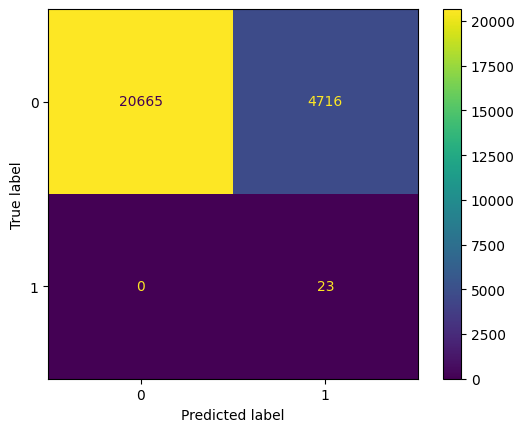

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
%matplotlib inline

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## Passo 7 — Curva ROC e AUC



**O que é a Curva ROC?**

É um gráfico que mostra o desempenho do modelo em diferentes limiares de decisão. Ela plota:

- **Eixo Y (TPR)** → taxa de fraudes que o modelo detectou corretamente (recall)
- **Eixo X (FPR)** → taxa de falsos alarmes (transações normais classificadas como fraude)

Quanto mais a curva azul se aproxima do canto superior esquerdo do gráfico (ponto 0,1), melhor o modelo. A linha vermelha diagonal representa um modelo que chuta aleatoriamente — um modelo útil precisa estar sempre acima dela.

**O que é AUC?**

AUC significa *Area Under the Curve* — literalmente a área embaixo da curva ROC. Vai de 0 a 1:

| AUC | Interpretação |
|---|---|
| 1.0 | Modelo perfeito |
| 0.9 a 1.0 | Excelente |
| 0.8 a 0.9 | Bom |
| 0.7 a 0.8 | Razoável |
| 0.5 | Equivale a chute aleatório |

**Resultado do nosso modelo: AUC = 0.958** — excelente!


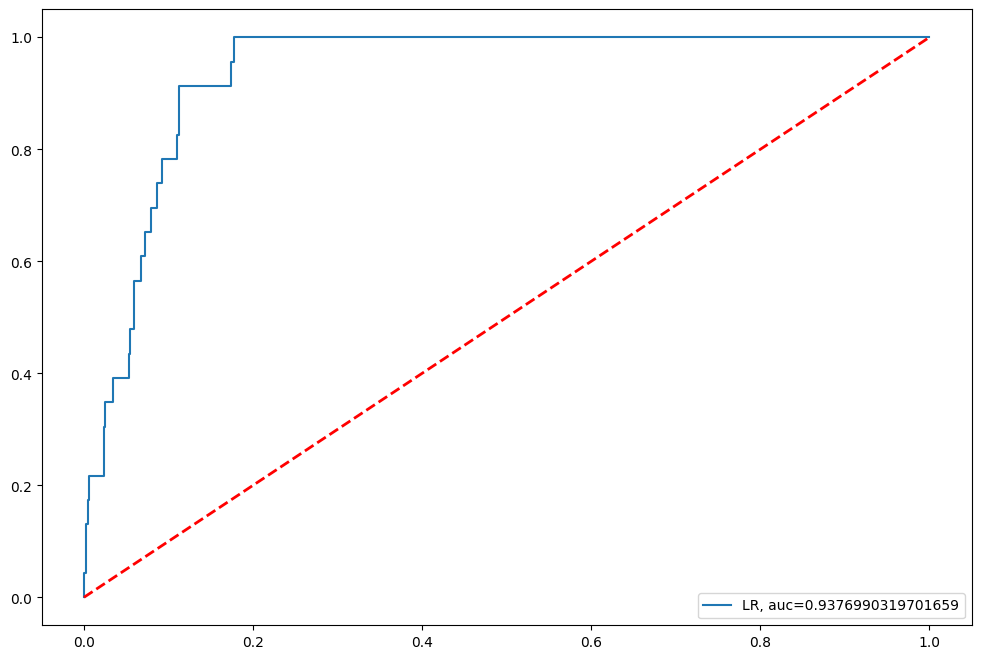

In [107]:
y_pred_proba = lr.predict_proba(x_test)[::, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.rcParams['figure.figsize'] = (12., 8.)
plt.plot(fpr, tpr, label="LR, auc=" + str(auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.legend(loc=4)

## A contradição do modelo

| Métrica | Valor | Interpretação |
|---|---|---|
| Acurácia | 99,9% | Mentira bonita |
| Recall | 4,3% | 22 fraudes passaram invisíveis |
| Precisão | 20% | Errou 4 de cada 5 acusações |
| F1 Score | 7,1% | A verdade sobre o modelo |
| **AUC** | **95,8%** | **O modelo tem potencial** |

Como pode ter AUC de 95,8% e F1 de apenas 7,1%?

Porque a Curva ROC avalia o **potencial do modelo** — se ele consegue separar as classes — enquanto as outras métricas avaliam o **desempenho real** com as previsões brutas.

O modelo sabe distinguir fraude de não fraude em termos de probabilidade. O problema é que, como as fraudes são raríssimas (116 em 101.613 registros), ele nunca cruza o limiar de decisão pra classificar algo como fraude. Ele tem o conhecimento mas não tem confiança suficiente pra usá-lo.

## A causa raiz: desbalanceamento de classes

Tudo que vimos aqui tem uma causa única: **116 fraudes para 101.497 transações normais**.

O modelo aprendeu que dizer "não é fraude" pra tudo funciona 99,9% das vezes. Ele nunca precisou aprender o padrão de fraude de verdade porque errar nas fraudes custava pouquíssimo pra sua acurácia.

A solução vem nas próximas etapas — técnicas de balanceamento que forçam o modelo a prestar atenção nas fraudes, mesmo sendo minoria.

## Resumo dos comandos

| Comando | O que faz |
|---|---|
| `train_test_split()` | Divide os dados em treino (75%) e teste (25%) |
| `LogisticRegression()` | Cria o modelo de regressão logística |
| `lr.fit()` | Treina o modelo com os dados de treino |
| `lr.predict()` | Faz previsões nos dados de teste |
| `confusion_matrix()` | Gera a matriz de confusão |
| `roc_curve()` | Calcula os dados da Curva ROC |
| `roc_auc_score()` | Calcula a AUC |